# Grammar Scoring Engine for Spoken Data

## 1. Problem Statement

The objective of this project is to predict the grammatical quality of spoken audio samples using continuous scores ranging from 0 to 5. The training dataset contains audio recordings with human-assigned grammar scores. The goal is to extract meaningful audio features, train regression models, evaluate their performance, and predict scores for unseen audio samples.

## 2. Approach

- Explore the training dataset and analyze the distribution of grammar scores.
- Extract audio features, including MFCCs, RMS energy, zero-crossing rate, spectral characteristics, pitch, and speech activity.
- Train and compare Random Forest, Extra Trees, and HistGradientBoosting regression models.
- Evaluate model performance using Root Mean Squared Error (RMSE) and Pearson correlation on a validation set.
- Select the best-performing model based on validation results and train it on the complete training dataset.
- Generate predictions for unseen audio samples, constrain scores to the range of 0–5, and save the submission file as a CSV.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_66.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_54.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_42.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_81.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_72.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final

### 1. Dataset Loading and Inspection

Load the training and test datasets, inspect their structure and sample records, and verify the number of available training audio files.

In [2]:

import os
import pandas as pd

# Dataset location
DATA_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

# Load CSV files
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

# Display dataset information
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nTraining samples:")
display(train_df.head())

print("\nTesting samples:")
display(test_df.head())

# Check audio folder
TRAIN_AUDIO_DIR = os.path.join(DATA_DIR, "train")

print("\nNumber of audio files:", len([
    f for f in os.listdir(TRAIN_AUDIO_DIR)
    if f.endswith(".wav")
]))


Training shape: (769, 2)
Testing shape: (216, 2)

Training samples:


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0



Testing samples:


,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1



Number of audio files: 769


### 2. Audio Sample Inspection

Load a sample audio file to verify its availability and examine its sample rate, duration, and shape. Listen to the recording to understand the type of audio used in the dataset.

In [3]:

import os
import soundfile as sf
from IPython.display import Audio, display

# Find one training audio file
audio_path = os.path.join(
    DATA_DIR, "train", train_df.iloc[0]["filename"]
)

# Check file and audio properties
print("Audio exists:", os.path.exists(audio_path))

audio, sample_rate = sf.read(audio_path)

print("Sample rate:", sample_rate, "Hz")
print("Duration:", round(len(audio) / sample_rate, 2), "seconds")
print("Audio shape:", audio.shape)

# Listen to the sample
display(Audio(audio, rate=sample_rate))


Audio exists: True
Sample rate: 16000 Hz
Duration: 60.51 seconds
Audio shape: (968134,)


### 3. Exploratory Data Analysis

Analyze the distribution of grammar scores using descriptive statistics and a histogram. This helps identify score frequencies and understand the distribution of target values in the training dataset.

Score statistics:


count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64


Number of samples per score:


label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64

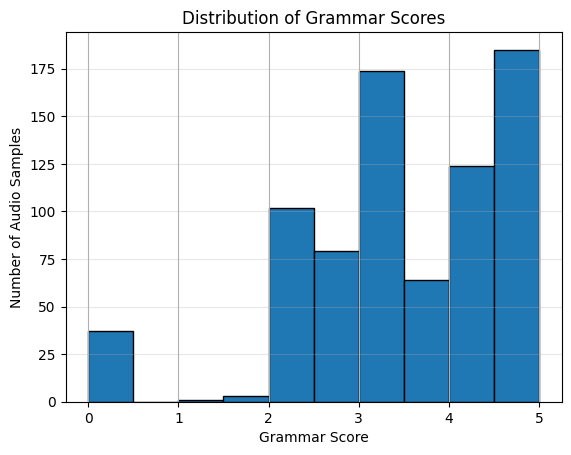

In [4]:

import matplotlib.pyplot as plt

# Summary of grammar scores
print("Score statistics:")
display(train_df["label"].describe())

print("\nNumber of samples per score:")
display(train_df["label"].value_counts().sort_index())

# Plot score distribution
train_df["label"].hist(bins=10, edgecolor="black")
plt.title("Distribution of Grammar Scores")
plt.xlabel("Grammar Score")
plt.ylabel("Number of Audio Samples")
plt.grid(axis="y", alpha=0.3)
plt.show()


### 4. Audio Feature Extraction

Extract acoustic features from each training recording, including Mel-Frequency Cepstral Coefficients (MFCCs), root mean square energy, zero-crossing rate, and spectral centroid. Calculate their mean and standard deviation to create numerical feature vectors for model training.

In [5]:

import os
import numpy as np
import librosa
import pandas as pd

from tqdm.auto import tqdm

# Audio folder
TRAIN_AUDIO_DIR = os.path.join(DATA_DIR, "train")
TEST_AUDIO_DIR = os.path.join(DATA_DIR, "test")

# Extract useful features from each recording
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=16000)

    features = []

    # MFCC: captures characteristics of the sound
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))

    # Energy: measures the strength of the audio
    rms = librosa.feature.rms(y=y)[0]
    features.extend([np.mean(rms), np.std(rms)])

    # Zero crossing rate: describes changes in the audio signal
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    features.extend([np.mean(zcr), np.std(zcr)])

    # Spectral centroid: describes frequency distribution
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    features.extend([np.mean(centroid), np.std(centroid)])

    return np.array(features, dtype=np.float32)


# Extract features for training data
X_train = []
for filename in tqdm(train_df["filename"], desc="Training audio"):
    path = os.path.join(TRAIN_AUDIO_DIR, filename)
    X_train.append(extract_features(path))

X_train = np.vstack(X_train)
y_train = train_df["label"].values

print("Training features shape:", X_train.shape)




Training audio:   0%|          | 0/769 [00:00<?, ?it/s]

Training features shape: (769, 46)


### 5. Baseline Model: Random Forest Regression

Split the dataset into 80% training and 20% validation sets. Train a Random Forest regressor and evaluate its predictions using Root Mean Squared Error (RMSE) and Pearson correlation to establish a baseline for comparison with other models.

In [6]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Split data: 80% training, 20% validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

# Train baseline model
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

model.fit(X_tr, y_tr)

# Predict validation scores
predictions = np.clip(model.predict(X_val), 0, 5)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_val, predictions))
pearson = pearsonr(y_val, predictions)[0]

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation Pearson Correlation: {pearson:.4f}")


Validation RMSE: 0.7476
Validation Pearson Correlation: 0.8347


### 6. Model Experimentation: Extra Trees Regressor

Train an Extra Trees regressor using the same training and validation split. Compare its RMSE and Pearson correlation with the Random Forest baseline to determine whether it improves prediction performance.

In [7]:

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Train a second model
extra_model = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    max_features=0.9,
    random_state=42,
    n_jobs=-1
)

extra_model.fit(X_tr, y_tr)

# Validation predictions
extra_predictions = np.clip(extra_model.predict(X_val), 0, 5)

# Evaluate
extra_rmse = np.sqrt(
    mean_squared_error(y_val, extra_predictions)
)
extra_pearson = pearsonr(y_val, extra_predictions)[0]

print(f"Extra Trees Validation RMSE: {extra_rmse:.4f}")
print(f"Extra Trees Validation Pearson: {extra_pearson:.4f}")


Extra Trees Validation RMSE: 0.7243
Extra Trees Validation Pearson: 0.8471


### 7. Extra Trees Model: Prediction Visualization

Visualize the actual grammar scores against the Extra Trees model's predicted scores. The dashed diagonal line represents perfect predictions, helping assess how closely the model estimates the true scores.

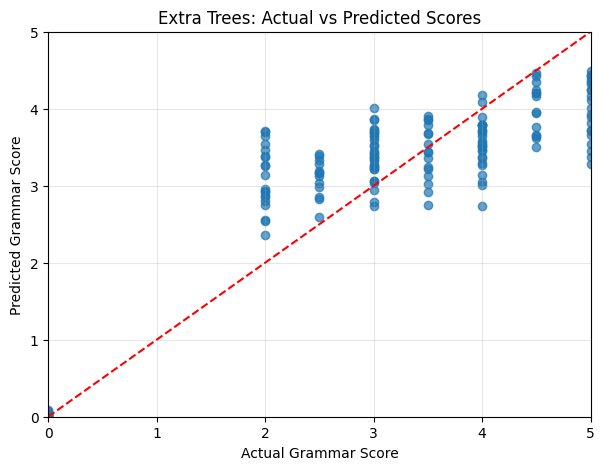

In [8]:

import matplotlib.pyplot as plt

# Plot actual vs predicted scores
plt.figure(figsize=(7, 5))
plt.scatter(y_val, extra_predictions, alpha=0.7)

plt.plot([0, 5], [0, 5], "r--")
plt.xlabel("Actual Grammar Score")
plt.ylabel("Predicted Grammar Score")
plt.title("Extra Trees: Actual vs Predicted Scores")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.grid(alpha=0.3)
plt.show()


### 8. Model Experimentation: HistGradientBoosting Regressor

Train a HistGradientBoosting regressor on the extracted audio features. Evaluate its performance using validation RMSE and Pearson correlation to compare it with the previous models and identify a stronger baseline.

In [9]:

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

model_hgb = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    l2_regularization=2.0,
    random_state=42
)

model_hgb.fit(X_tr, y_tr)

pred_hgb = np.clip(model_hgb.predict(X_val), 0, 5)

rmse_hgb = np.sqrt(mean_squared_error(y_val, pred_hgb))
pearson_hgb = pearsonr(y_val, pred_hgb)[0]

print(f"HistGradientBoosting RMSE: {rmse_hgb:.4f}")
print(f"HistGradientBoosting Pearson: {pearson_hgb:.4f}")


HistGradientBoosting RMSE: 0.7179
HistGradientBoosting Pearson: 0.8480


### 9. Additional Audio Feature Extraction

Define additional features to capture pitch variation, approximate speaking activity, spectral bandwidth, and spectral roll-off. These features complement the existing MFCC-based features and may improve grammar-score prediction when combined with them.

In [10]:

def extract_extra_features(file_path):
    y, sr = librosa.load(file_path, sr=16000)

    # Pitch estimation
    pitches = librosa.yin(
        y, fmin=70, fmax=400, sr=sr
    )
    pitch_mean = np.mean(pitches)
    pitch_std = np.std(pitches)

    # Approximate speaking activity using short-time energy
    rms = librosa.feature.rms(
        y=y, frame_length=2048, hop_length=512
    )[0]

    threshold = max(np.max(rms) * 0.1, 1e-5)
    active_ratio = np.mean(rms > threshold)

    # Spectral bandwidth and roll-off
    bandwidth = librosa.feature.spectral_bandwidth(
        y=y, sr=sr
    )[0]
    rolloff = librosa.feature.spectral_rolloff(
        y=y, sr=sr
    )[0]

    return [
        pitch_mean,
        pitch_std,
        active_ratio,
        np.mean(bandwidth),
        np.std(bandwidth),
        np.mean(rolloff),
        np.std(rolloff)
    ]

print("Feature extraction function is ready.")


Feature extraction function is ready.


### 10. Combining Audio Features

Extract the additional pitch, speaking-activity, and spectral features from all training recordings. Combine them with the original acoustic features to create a richer feature set for training and evaluating the regression models.

In [11]:

from tqdm.auto import tqdm
import numpy as np
import os

# Extract additional features from all training audio files
X_extra = []

for filename in tqdm(train_df["filename"], desc="Extra features"):
    path = os.path.join(TRAIN_AUDIO_DIR, filename)
    X_extra.append(extract_extra_features(path))

X_extra = np.asarray(X_extra, dtype=np.float32)

# Combine original and additional features
X_combined = np.hstack([X_train, X_extra])

print("Original features:", X_train.shape)
print("Additional features:", X_extra.shape)
print("Combined features:", X_combined.shape)


Extra features:   0%|          | 0/769 [00:00<?, ?it/s]

Original features: (769, 46)
Additional features: (769, 7)
Combined features: (769, 53)


### 11. Evaluating the Combined Feature Model

Train a HistGradientBoosting regressor using the combined audio features and the same validation split. Compare its RMSE and Pearson correlation with the previous models to assess whether the additional features improve prediction performance.

In [12]:

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Use the same validation split for a fair comparison
X_tr_new = X_combined[ X_tr.index ] if hasattr(X_tr, "index") else None


### 11. Final Model Comparison Using Combined Features

Evaluate HistGradientBoosting using the combined acoustic feature set and a consistent 80:20 training-validation split. Measure RMSE and Pearson correlation to determine whether the additional pitch, activity, and spectral features improve prediction performance.

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

indices = np.arange(len(y_train))
idx_tr, idx_val = train_test_split(
    indices, test_size=0.2, random_state=42
)

model_combined = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    l2_regularization=2.0,
    random_state=42
)

model_combined.fit(X_combined[idx_tr], y_train[idx_tr])

pred_combined = np.clip(
    model_combined.predict(X_combined[idx_val]), 0, 5
)

rmse_combined = np.sqrt(
    mean_squared_error(y_train[idx_val], pred_combined)
)
pearson_combined = pearsonr(
    y_train[idx_val], pred_combined
)[0]

print(f"Combined Features RMSE: {rmse_combined:.4f}")
print(f"Combined Features Pearson: {pearson_combined:.4f}")


Combined Features RMSE: 0.7040
Combined Features Pearson: 0.8544


### 11.1. Actual vs. Predicted Grammar Scores

Compare the actual validation scores with predictions from the combined-feature HistGradientBoosting model. The diagonal reference line indicates perfect agreement between actual and predicted scores.

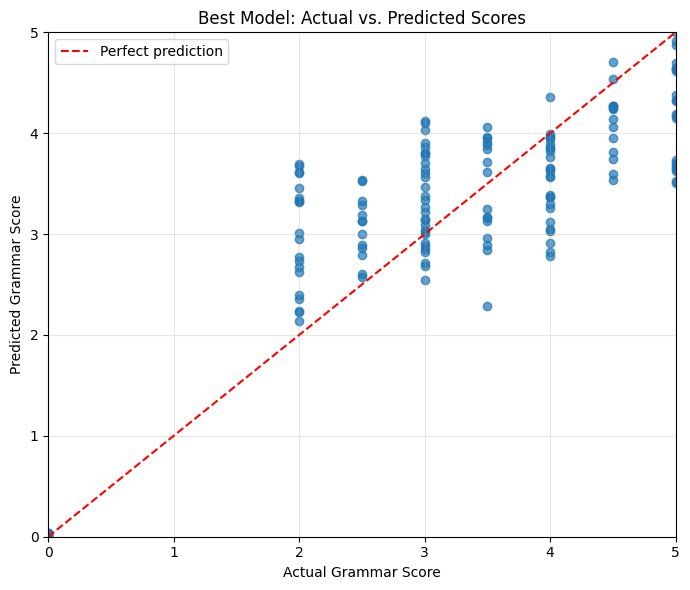

In [14]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_train[idx_val],
    pred_combined,
    alpha=0.7
)

plt.plot([0, 5], [0, 5], "r--", label="Perfect prediction")

plt.xlabel("Actual Grammar Score")
plt.ylabel("Predicted Grammar Score")
plt.title("Best Model: Actual vs. Predicted Scores")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 11.2. Validation Residual Analysis

Examine the distribution of residuals, calculated as actual scores minus predicted scores. This helps identify systematic overprediction or underprediction and understand the model's validation errors.

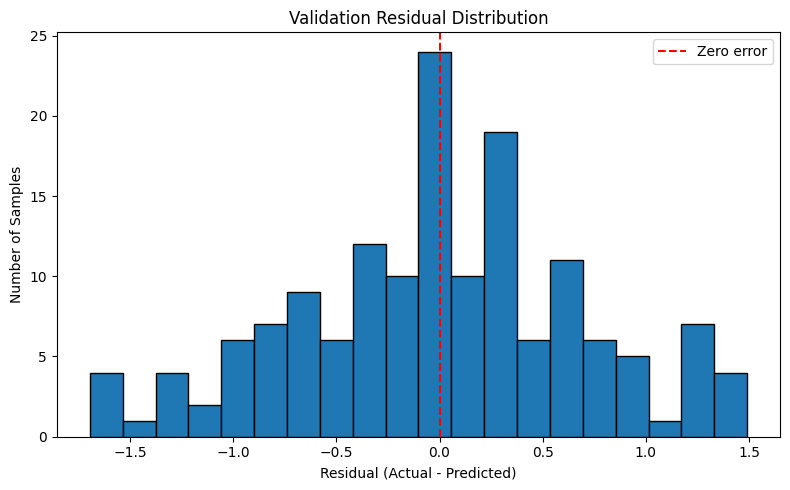

In [15]:
residuals = y_train[idx_val] - pred_combined

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20, edgecolor="black")
plt.axvline(0, color="red", linestyle="--", label="Zero error")

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Number of Samples")
plt.title("Validation Residual Distribution")
plt.legend()
plt.tight_layout()
plt.show()

### 12. Model Performance Comparison

Compare the validation RMSE and Pearson correlation of all four model experiments. The combined-feature HistGradientBoosting model achieves the lowest RMSE and highest Pearson correlation, making it the best-performing model among the approaches tested.

In [16]:

results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Extra Trees",
        "HistGradientBoosting",
        "HistGradientBoosting + Extra Audio Features"
    ],
    "Validation RMSE": [
        0.7476, 0.7243, 0.7179, 0.7040
    ],
    "Pearson Correlation": [
        0.8347, 0.8471, 0.8480, 0.8544
    ]
})

display(results)


,Model,Validation RMSE,Pearson Correlation
0,Random Forest,0.7476,0.8347
1,Extra Trees,0.7243,0.8471
2,HistGradientBoosting,0.7179,0.8480
3,HistGradientBoosting + Extra Audio Features,0.7040,0.8544


### 12.1. Visual Comparison of Model Performance

Visualize the validation RMSE and Pearson correlation of the evaluated models. Lower RMSE indicates smaller prediction errors, while higher Pearson correlation indicates a stronger relationship between actual and predicted grammar scores.

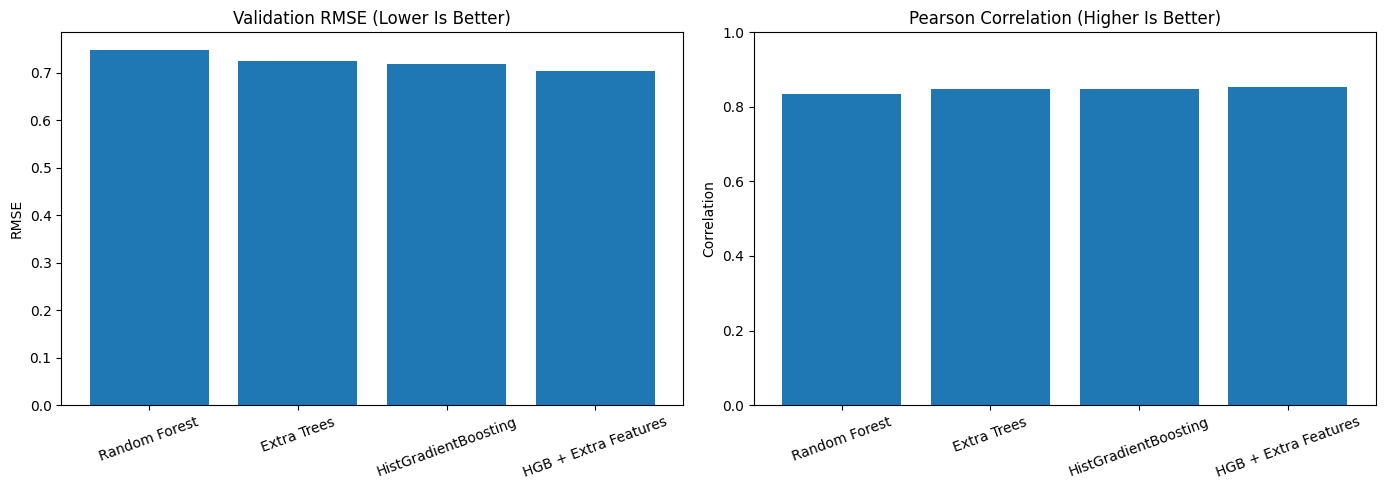

In [17]:
# Shorter labels improve readability
plot_results = results.copy()
plot_results["Model"] = [
    "Random Forest",
    "Extra Trees",
    "HistGradientBoosting",
    "HGB + Extra Features"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(plot_results["Model"], plot_results["Validation RMSE"])
axes[0].set_title("Validation RMSE (Lower Is Better)")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(
    plot_results["Model"],
    plot_results["Pearson Correlation"]
)
axes[1].set_title("Pearson Correlation (Higher Is Better)")
axes[1].set_ylabel("Correlation")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### 13. Final Model Training and Training RMSE

Train the selected HistGradientBoosting regressor on the complete training dataset using the combined audio features. Calculate the training RMSE to satisfy the assessment requirement and measure prediction error on the training samples.

In [18]:

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Train on all training samples using our best features
final_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    l2_regularization=2.0,
    random_state=42
)

final_model.fit(X_combined, y_train)

# Training predictions and compulsory training RMSE
train_predictions = np.clip(
    final_model.predict(X_combined), 0, 5
)

training_rmse = np.sqrt(
    mean_squared_error(y_train, train_predictions)
)

print(f"Training RMSE: {training_rmse:.4f}")


Training RMSE: 0.2054


### 14. Submission Format Verification

Inspect the provided sample submission and compare its filenames and structure with the test dataset. This check helps identify inconsistencies before generating the final predictions and ensures the submission is prepared using the correct test samples.

In [19]:
sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_sub.shape)
print("Test columns:", test_df.columns.tolist())
print("Submission columns:", sample_sub.columns.tolist())

display(sample_sub.head())

print("Unique test filenames:", test_df["filename"].nunique())
print("Unique submission filenames:", sample_sub["filename"].nunique())

print("Test files missing from sample submission:")
print(set(test_df["filename"]) - set(sample_sub["filename"]))

Test shape: (216, 2)
Sample submission shape: (204, 2)
Test columns: ['filename', 'label']
Submission columns: ['filename', 'label']


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1


Unique test filenames: 216
Unique submission filenames: 204
Test files missing from sample submission:
{'audio_68.wav', 'audio_142.wav', 'audio_148.wav', 'audio_166.wav', 'audio_213.wav', 'audio_207.wav', 'audio_6.wav', 'audio_100.wav', 'audio_30.wav', 'audio_46.wav', 'audio_191.wav', 'audio_189.wav', 'audio_77.wav', 'audio_19.wav', 'audio_50.wav', 'audio_48.wav', 'audio_154.wav', 'audio_147.wav', 'audio_4.wav', 'audio_127.wav', 'audio_83.wav', 'audio_94.wav', 'audio_186.wav', 'audio_137.wav', 'audio_206.wav', 'audio_20.wav', 'audio_181.wav', 'audio_143.wav', 'audio_7.wav', 'audio_122.wav', 'audio_21.wav', 'audio_139.wav', 'audio_81.wav', 'audio_5.wav', 'audio_141.wav', 'audio_26.wav', 'audio_54.wav', 'audio_138.wav', 'audio_51.wav', 'audio_124.wav', 'audio_163.wav', 'audio_18.wav', 'audio_169.wav', 'audio_172.wav', 'audio_31.wav', 'audio_156.wav', 'audio_28.wav', 'audio_109.wav', 'audio_204.wav', 'audio_106.wav', 'audio_103.wav', 'audio_192.wav', 'audio_125.wav', 'audio_197.wav', 'aud

### 15. Identifying Dataset Inconsistencies

Compare the test dataset with the provided sample submission to identify missing, extra, or mismatched filenames. This verification helps explain the discrepancy between the two files and guides the preparation of predictions for the actual test dataset.

In [20]:
print("Test rows:", len(test_df))
print("Unique test filenames:", test_df["filename"].nunique())
print("Sample submission rows:", len(sample_sub))
print("Unique sample filenames:", sample_sub["filename"].nunique())

missing = set(test_df["filename"]) - set(sample_sub["filename"])
extra = set(sample_sub["filename"]) - set(test_df["filename"])

print("\nTest filenames missing from sample submission:", len(missing))
print(sorted(missing))

print("\nFilenames in sample submission but not test:", len(extra))
print(sorted(extra))

display(test_df.head())
display(sample_sub.head())

Test rows: 216
Unique test filenames: 216
Sample submission rows: 204
Unique sample filenames: 204

Test filenames missing from sample submission: 191
['audio_0.wav', 'audio_1.wav', 'audio_10.wav', 'audio_100.wav', 'audio_101.wav', 'audio_102.wav', 'audio_103.wav', 'audio_104.wav', 'audio_105.wav', 'audio_106.wav', 'audio_107.wav', 'audio_109.wav', 'audio_11.wav', 'audio_110.wav', 'audio_111.wav', 'audio_112.wav', 'audio_113.wav', 'audio_114.wav', 'audio_115.wav', 'audio_116.wav', 'audio_118.wav', 'audio_119.wav', 'audio_12.wav', 'audio_120.wav', 'audio_121.wav', 'audio_122.wav', 'audio_123.wav', 'audio_124.wav', 'audio_125.wav', 'audio_126.wav', 'audio_127.wav', 'audio_129.wav', 'audio_131.wav', 'audio_132.wav', 'audio_133.wav', 'audio_134.wav', 'audio_135.wav', 'audio_136.wav', 'audio_137.wav', 'audio_138.wav', 'audio_139.wav', 'audio_140.wav', 'audio_141.wav', 'audio_142.wav', 'audio_143.wav', 'audio_144.wav', 'audio_145.wav', 'audio_146.wav', 'audio_147.wav', 'audio_148.wav', 'audi

,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1


### 16. Test Audio Feature Extraction

Extract the same acoustic and additional features from each test audio recording using the preprocessing pipeline applied to the training data. Combine these features to prepare the test samples for prediction with the final trained model.

In [21]:
from tqdm.auto import tqdm
import numpy as np
import os

TEST_AUDIO_DIR = os.path.join(DATA_DIR, "test")

X_test_basic = []
X_test_extra = []

for filename in tqdm(test_df["filename"], desc="Test audio features"):
    path = os.path.join(TEST_AUDIO_DIR, filename)

    X_test_basic.append(extract_features(path))
    X_test_extra.append(extract_extra_features(path))

X_test_basic = np.asarray(X_test_basic, dtype=np.float32)
X_test_extra = np.asarray(X_test_extra, dtype=np.float32)

X_test_combined = np.hstack([X_test_basic, X_test_extra])

print("Test feature shape:", X_test_combined.shape)
print("Expected rows:", len(test_df))

Test audio features:   0%|          | 0/216 [00:00<?, ?it/s]

Test feature shape: (216, 53)
Expected rows: 216


### 17. Generate Final Predictions and Submission

Use the final trained model to predict grammar scores for the test audio samples. Clip predictions to the valid score range of 0–5 and save the results in `submission.csv` with the required filename and label columns. Verify the submission shape and check for missing predictions.

In [22]:
test_predictions = np.clip(
    final_model.predict(X_test_combined),
    0,
    5
)

submission = pd.DataFrame({
    "filename": test_df["filename"].values,
    "label": test_predictions
})

submission.to_csv("submission.csv", index=False)

print("Submission shape:", submission.shape)
display(submission.head())
print("Missing predictions:", submission["label"].isna().sum())

Submission shape: (216, 2)


,filename,label
0,audio_128.wav,3.363101
1,audio_156.wav,4.338264
2,audio_19.wav,3.460341
3,audio_108.wav,2.387611
4,audio_206.wav,3.511643


Missing predictions: 0


### 18. Final Submission Validation

Perform final checks to confirm that the submission contains all 216 test samples in the correct order, with no missing predictions and all predicted grammar scores within the valid range of 0–5. Verify that the submission file has been saved successfully.

In [23]:
assert len(submission) == len(test_df) == 216
assert submission["filename"].equals(test_df["filename"])
assert submission["label"].notna().all()
assert submission["label"].between(0, 5).all()

print("All submission checks passed!")
print("Prediction range:",
      submission["label"].min(),
      "to",
      submission["label"].max())

print("Saved file:", os.path.abspath("submission.csv"))

All submission checks passed!
Prediction range: 2.125162023072838 to 4.549148300343003
Saved file: /kaggle/working/submission.csv


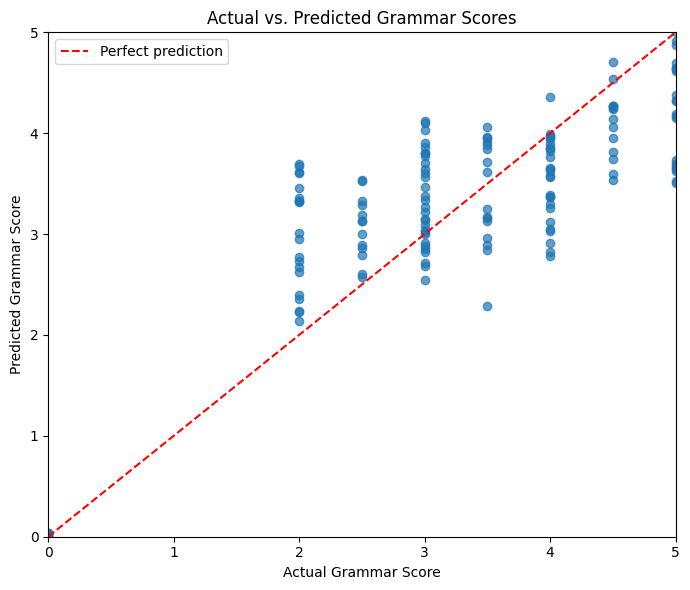

In [24]:
plt.figure(figsize=(7, 6))
plt.scatter(
    y_train[idx_val],
    pred_combined,
    alpha=0.7
)

plt.plot([0, 5], [0, 5], "r--", label="Perfect prediction")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel("Actual Grammar Score")
plt.ylabel("Predicted Grammar Score")
plt.title("Actual vs. Predicted Grammar Scores")
plt.legend()
plt.tight_layout()
plt.show()